laplaciano 


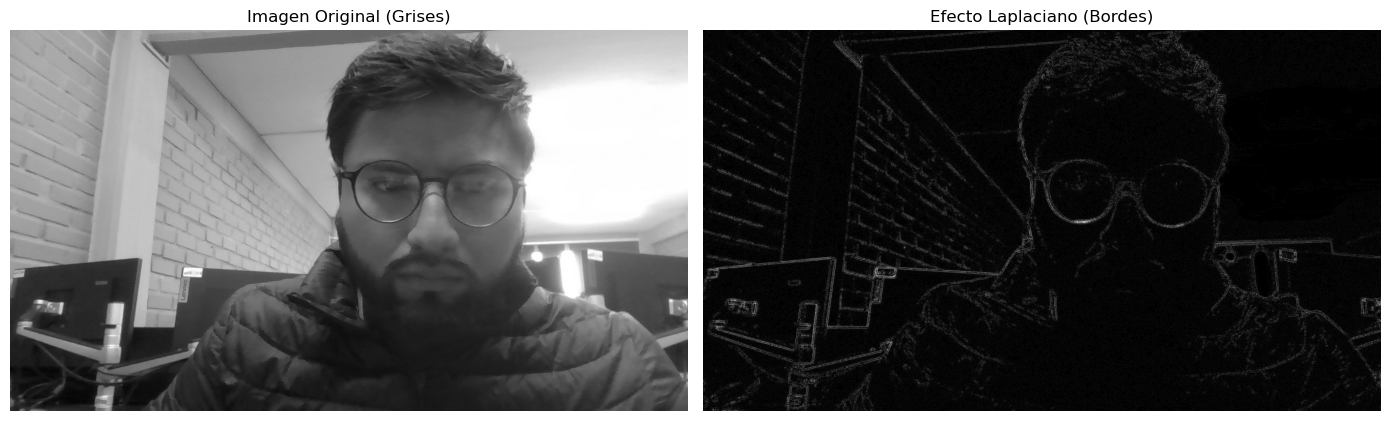

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 1. Definir la ruta de tu imagen usando una 'r' al principio (raw string)
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\fotito.jpeg'

# 2. Cargar la imagen en escala de grises
img = cv2.imread(ruta, 0)

# Verificación de carga
if img is None:
    print(f"Error: No se encontró la imagen en: {ruta}")
    print("Asegúrate de que la extensión (.jpeg) y la carpeta sean correctas.")
else:
    # 3. Aplicar un suavizado previo (opcional pero recomendado para el ruido)
    # Si quieres el Laplaciano puro, puedes comentar la siguiente línea
    img_blur = cv2.GaussianBlur(img, (3, 3), 0)

    # 4. Calcular el Laplaciano
    # Usamos CV_64F para no perder la información de los bordes negativos
    laplacian = cv2.Laplacian(img_blur, cv2.CV_64F)
    
    # Convertir a valor absoluto y a formato de imagen de 8 bits
    laplacian_abs = np.uint8(np.absolute(laplacian))

    # 5. Mostrar los resultados lado a lado
    plt.figure(figsize=(14, 7))

    # Lado izquierdo: Original
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Imagen Original (Grises)')
    plt.axis('off')

    # Lado derecho: Laplaciano
    plt.subplot(1, 2, 2)
    plt.imshow(laplacian_abs, cmap='gray')
    plt.title('Efecto Laplaciano (Bordes)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

laplaciano gussiano 

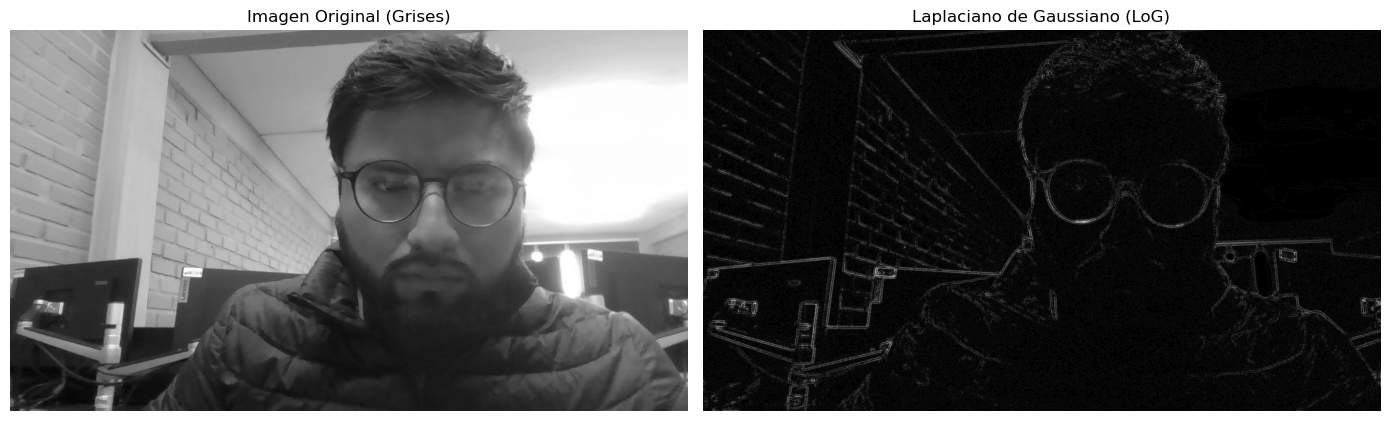

In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 1. Definir la ruta de tu imagen usando una 'r' al principio (raw string)
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\fotito.jpeg'

# 2. Cargar la imagen en escala de grises
img = cv2.imread(ruta, 0)

# Verificación de carga
if img is None:
    print(f"Error: No se encontró la imagen en: {ruta}")
    print("Asegúrate de que la extensión (.jpeg) y la carpeta sean correctas.")
else:
    # 3. Paso de Gaussiano: Suavizado previo para reducir el ruido (CRUCIAL para LoG)
    # (5, 5) es el tamaño del kernel de desenfoque. Aumentar esto suaviza más.
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)

    # 4. Paso de Laplaciano: Calcular la segunda derivada sobre la imagen suavizada
    # Usamos CV_64F para no perder la información de los bordes negativos
    laplacian = cv2.Laplacian(img_blur, cv2.CV_64F)
    
    # Convertir a valor absoluto y a formato de imagen de 8 bits
    # Esto une los 'cambios positivos' y 'cambios negativos' en un solo borde blanco
    log_result = np.uint8(np.absolute(laplacian))

    # 5. Mostrar los resultados lado a lado
    plt.figure(figsize=(14, 7))

    # Lado izquierdo: Original
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Imagen Original (Grises)')
    plt.axis('off')

    # Lado derecho: Laplaciano de Gaussiano
    plt.subplot(1, 2, 2)
    plt.imshow(log_result, cmap='gray')
    plt.title('Laplaciano de Gaussiano (LoG)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()